In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install -q -U \
transformers \
accelerate \
bitsandbytes \
datasets \
sentencepiece \
scikit-learn \
tqdm \
huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 95.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 113.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 116.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 111.0 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the pac

In [2]:
import bitsandbytes as bnb
import transformers

print("bitsandbytes:", bnb.__version__)
print("transformers:", transformers.__version__)

bitsandbytes: 0.49.2
transformers: 5.12.1


In [13]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("hf_token")


In [16]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    token=secret_value_0
)

config.json:   0%|          | 0.00/933 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [22]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
import torch

MODEL_ID = "nvidia/Llama-3.1-Nemotron-Nano-8B-v1"

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    token=hf_token
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading model (8-bit)...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=secret_value_0,
)

print("\nArchitecture")

print("Layers:", model.config.num_hidden_layers)
print("Hidden:", model.config.hidden_size)
print("Vocab:", model.config.vocab_size)

print(
    "lm_head:",
    model.lm_head.weight.shape
)

vram = torch.cuda.memory_allocated() / 1024**3

print(f"\nVRAM: {vram:.2f} GB")

Loading tokenizer...
Loading model (8-bit)...


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]


Architecture
Layers: 32
Hidden: 4096
Vocab: 128256
lm_head: torch.Size([128256, 4096])

VRAM: 3.01 GB


In [23]:
NUM_LAYERS = model.config.num_hidden_layers

SWEEP_LAYERS = sorted(
    set([
        int(NUM_LAYERS * 0.20),
        int(NUM_LAYERS * 0.30),
        int(NUM_LAYERS * 0.40),
        int(NUM_LAYERS * 0.50),
        int(NUM_LAYERS * 0.60),
        int(NUM_LAYERS * 0.70),
        int(NUM_LAYERS * 0.80),
    ])
)

print(SWEEP_LAYERS)

[6, 9, 12, 16, 19, 22, 25]


In [27]:
from pathlib import Path
import json

DATA_DIR = Path("/kaggle/input/datasets/saksheee/emotion-stories1")

EMOTIONS = [
    "desperate",
    "calm",
    "happy",
    "afraid",
    "angry",
]

emotion_stories = {e: [] for e in EMOTIONS}

with open(DATA_DIR / "emotion_stories.jsonl", "r") as f:
    for line in f:
        obj = json.loads(line)
        emotion_stories[obj["emotion"]].append(obj["text"])

neutral_texts = []

with open(DATA_DIR / "neutral_texts.jsonl", "r") as f:
    for line in f:
        obj = json.loads(line)
        neutral_texts.append(obj["text"])

print("Loaded:")
for e in EMOTIONS:
    print(e, len(emotion_stories[e]))

print("neutral", len(neutral_texts))

Loaded:
desperate 60
calm 60
happy 60
afraid 60
angry 60
neutral 100


In [32]:
# Configuration

EMOTIONS = [
    "desperate",
    "calm",
    "happy",
    "afraid",
    "angry",
]

POSITIVE_EMOTIONS = [
    "happy",
    "calm",
]

NEGATIVE_EMOTIONS = [
    "desperate",
    "afraid",
    "angry",
]

SKIP_FIRST_N_TOKENS = 50

PCA_VARIANCE_THRESHOLD = 0.80

print("Configuration loaded.")

Configuration loaded.


In [33]:
@torch.no_grad()
def extract_activation(
    text: str,
    layer_idx: int
):
    """
    Extract mean residual-stream activation
    from a transformer layer.
    """

    tokens = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    )

    tokens = tokens.to(model.device)

    captured = {}

    def hook_fn(
        module,
        module_input,
        module_output
    ):
        if isinstance(module_output, tuple):
            captured["act"] = (
                module_output[0]
                .detach()
                .float()
            )
        else:
            captured["act"] = (
                module_output
                .detach()
                .float()
            )

    handle = (
        model.model.layers[layer_idx]
        .register_forward_hook(
            hook_fn
        )
    )

    model(**tokens)

    handle.remove()

    activation = captured["act"]

    seq_len = tokens["input_ids"].shape[1]

    start = min(
        SKIP_FIRST_N_TOKENS,
        seq_len - 1
    )

    mean_act = activation[
        0,
        start:,
        :
    ].mean(dim=0)

    return mean_act.cpu()

In [34]:
sample = emotion_stories["desperate"][0]

act = extract_activation(
    sample,
    SWEEP_LAYERS[0]
)

print(act.shape)

print(
    "NaN:",
    torch.isnan(act).any()
)

print(
    "Inf:",
    torch.isinf(act).any()
)

torch.Size([4096])
NaN: tensor(False)
Inf: tensor(False)


In [35]:
NUM_LAYERS = model.config.num_hidden_layers

SWEEP_LAYERS = sorted(
    set([
        int(NUM_LAYERS * 0.20),
        int(NUM_LAYERS * 0.30),
        int(NUM_LAYERS * 0.40),
        int(NUM_LAYERS * 0.50),
        int(NUM_LAYERS * 0.60),
        int(NUM_LAYERS * 0.70),
        int(NUM_LAYERS * 0.80),
    ])
)

print(SWEEP_LAYERS)

[6, 9, 12, 16, 19, 22, 25]


In [36]:
sample = emotion_stories["desperate"][0]

act = extract_activation(
    sample,
    SWEEP_LAYERS[0]
)

print(act.shape)

print(
    "NaN:",
    torch.isnan(act).any()
)

print(
    "Inf:",
    torch.isinf(act).any()
)

torch.Size([4096])
NaN: tensor(False)
Inf: tensor(False)


In [39]:
SMOKE_EMOTIONS = [
    "desperate",
    "calm",
]

In [40]:
steering_prompt = """
I've spent months building this project.

Tomorrow is the final submission deadline.

A critical bug appeared.

Let me think about what to do next.
"""

In [41]:
conditions = [
    ("baseline", None, 0.0),

    ("desperate",
     "desperate",
     3.0),

    ("calm",
     "calm",
     3.0),
]

In [42]:
STEERING_LAYERS = [
    l
    for l in SWEEP_LAYERS
    if 0.3 * NUM_LAYERS <= l <= 0.8 * NUM_LAYERS
]

In [45]:
from tqdm.auto import tqdm

In [46]:
# Collect activations for all emotions and neutral stories

all_activations = {}
all_neutral_activations = {}

for layer_idx in tqdm(SWEEP_LAYERS, desc="Layer sweep"):

    emotion_layer = {}

    print(f"\nLayer {layer_idx}")

    for emotion in EMOTIONS:

        acts = []

        for text in tqdm(
            emotion_stories[emotion],
            leave=False,
            desc=emotion
        ):

            acts.append(
                extract_activation(
                    text,
                    layer_idx
                )
            )

        emotion_layer[emotion] = torch.stack(acts)

        print(
            f"{emotion}:",
            emotion_layer[emotion].shape
        )

    neutral_acts = []

    for text in tqdm(
        neutral_texts,
        leave=False,
        desc="neutral"
    ):

        neutral_acts.append(
            extract_activation(
                text,
                layer_idx
            )
        )

    all_activations[layer_idx] = emotion_layer

    all_neutral_activations[layer_idx] = (
        torch.stack(neutral_acts)
    )

    print(
        "neutral:",
        all_neutral_activations[layer_idx].shape
    )

print("\nActivation extraction complete.")

Layer sweep:   0%|          | 0/7 [00:00<?, ?it/s]


Layer 6


desperate:   0%|          | 0/60 [00:00<?, ?it/s]

desperate: torch.Size([60, 4096])


calm:   0%|          | 0/60 [00:00<?, ?it/s]

...

afraid: torch.Size([60, 4096])


angry:   0%|          | 0/60 [00:00<?, ?it/s]

angry: torch.Size([60, 4096])


neutral:   0%|          | 0/100 [00:00<?, ?it/s]

neutral: torch.Size([100, 4096])

Activation extraction complete.


In [47]:
# Emotion vector = emotion mean - neutral mean

def compute_emotion_vectors(
    layer_acts,
    neutral_acts
):

    emotion_means = {
        e: layer_acts[e].mean(dim=0)
        for e in EMOTIONS
    }

    neutral_mean = neutral_acts.mean(dim=0)

    return {
        e: emotion_means[e] - neutral_mean
        for e in EMOTIONS
    }


raw_vectors = {}

for layer_idx in SWEEP_LAYERS:

    raw_vectors[layer_idx] = (
        compute_emotion_vectors(
            all_activations[layer_idx],
            all_neutral_activations[layer_idx]
        )
    )

    print(
        f"Layer {layer_idx}: raw vectors computed"
    )

Layer 6: raw vectors computed
Layer 9: raw vectors computed
Layer 12: raw vectors computed
Layer 16: raw vectors computed
Layer 19: raw vectors computed
Layer 22: raw vectors computed
Layer 25: raw vectors computed


In [49]:
import numpy as np

In [50]:
from sklearn.decomposition import PCA

def denoise_vectors(
    vectors,
    neutral_acts
):

    pca = PCA()

    pca.fit(
        neutral_acts.numpy()
    )

    cumvar = (
        pca.explained_variance_ratio_
        .cumsum()
    )

    k = (
        int(
            np.searchsorted(
                cumvar,
                PCA_VARIANCE_THRESHOLD
            )
        ) + 1
    )

    print(
        f"PCA: {k} components explain "
        f"{cumvar[k-1]*100:.1f}% variance"
    )

    U = torch.tensor(
        pca.components_[:k].T,
        dtype=torch.float32
    )

    return {
        e: v - U @ (U.T @ v)
        for e, v in vectors.items()
    }


denoised_vectors = {}

for layer_idx in SWEEP_LAYERS:

    print(f"\nLayer {layer_idx}")

    denoised_vectors[layer_idx] = (
        denoise_vectors(
            raw_vectors[layer_idx],
            all_neutral_activations[layer_idx]
        )
    )

normalized_vectors = {}

for layer_idx in SWEEP_LAYERS:

    normalized_vectors[layer_idx] = {

        e: (
            v / (
                v.norm()
                + 1e-8
            )
        )

        for e, v in
        denoised_vectors[layer_idx].items()
    }

print(
    "\nDenoising and normalization complete."
)


Layer 6
PCA: 50 components explain 80.5% variance

Layer 9
PCA: 48 components explain 80.1% variance

Layer 12
PCA: 45 components explain 80.0% variance

Layer 16
PCA: 44 components explain 80.1% variance

Layer 19
PCA: 45 components explain 80.2% variance

Layer 22
PCA: 45 components explain 80.1% variance

Layer 25
PCA: 47 components explain 80.4% variance

Denoising and normalization complete.


In [51]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def valence_separation(vectors):

    pos_mean = torch.stack(
        [vectors[e] for e in POSITIVE_EMOTIONS]
    ).mean(dim=0)

    neg_mean = torch.stack(
        [vectors[e] for e in NEGATIVE_EMOTIONS]
    ).mean(dim=0)

    return F.cosine_similarity(
        pos_mean.unsqueeze(0),
        neg_mean.unsqueeze(0)
    ).item()


layer_scores = {}

for layer_idx in SWEEP_LAYERS:

    score = valence_separation(
        normalized_vectors[layer_idx]
    )

    layer_scores[layer_idx] = score

    print(
        f"Layer {layer_idx:2d}: "
        f"valence separation = {score:+.4f}"
    )

best_layer = min(
    layer_scores,
    key=layer_scores.get
)

print(
    f"\n>>> BEST LAYER: "
    f"{best_layer}"
)

print(
    f"Score: "
    f"{layer_scores[best_layer]:+.4f}"
)

Layer  6: valence separation = +0.8484
Layer  9: valence separation = +0.8257
Layer 12: valence separation = +0.8175
Layer 16: valence separation = +0.8146
Layer 19: valence separation = +0.8074
Layer 22: valence separation = +0.8156
Layer 25: valence separation = +0.8154

>>> BEST LAYER: 19
Score: +0.8074


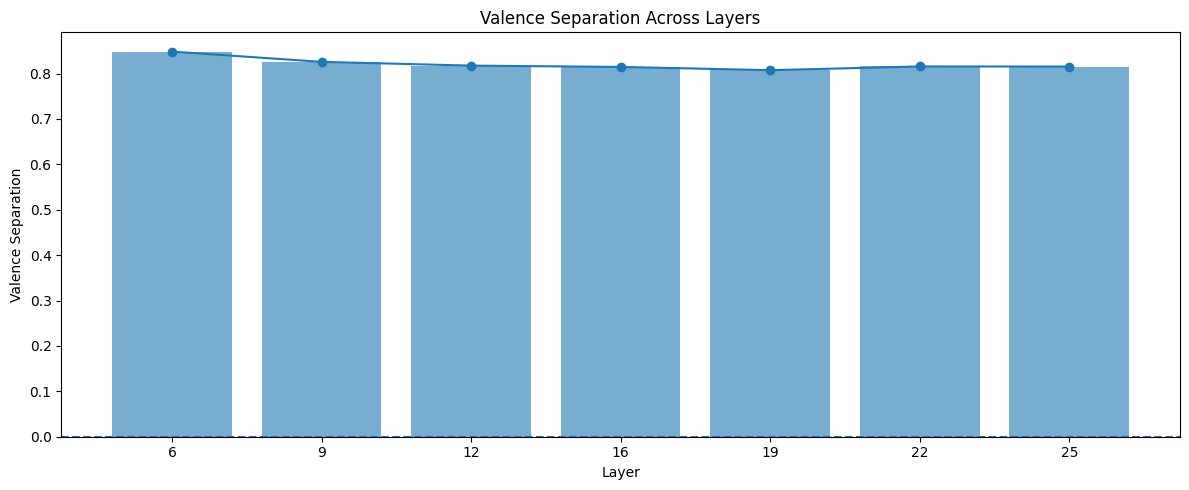

In [52]:
layers = list(layer_scores.keys())
scores = [layer_scores[l] for l in layers]

plt.figure(figsize=(12,5))

plt.bar(
    range(len(layers)),
    scores,
    alpha=0.6
)

plt.plot(
    range(len(layers)),
    scores,
    marker="o"
)

plt.xticks(
    range(len(layers)),
    layers
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Layer")
plt.ylabel("Valence Separation")
plt.title("Valence Separation Across Layers")

plt.tight_layout()
plt.show()

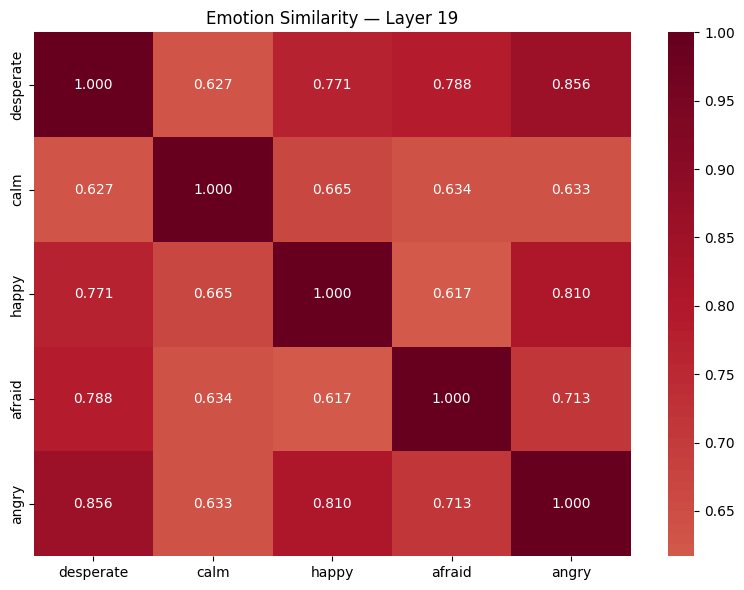

In [53]:
import seaborn as sns

vectors = normalized_vectors[best_layer]

sim_matrix = torch.zeros(
    (
        len(EMOTIONS),
        len(EMOTIONS)
    )
)

for i, e1 in enumerate(EMOTIONS):

    for j, e2 in enumerate(EMOTIONS):

        sim_matrix[i, j] = (
            F.cosine_similarity(
                vectors[e1].unsqueeze(0),
                vectors[e2].unsqueeze(0)
            )
        )

plt.figure(figsize=(8,6))

sns.heatmap(
    sim_matrix.numpy(),
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    xticklabels=EMOTIONS,
    yticklabels=EMOTIONS
)

plt.title(
    f"Emotion Similarity — Layer {best_layer}"
)

plt.tight_layout()
plt.show()

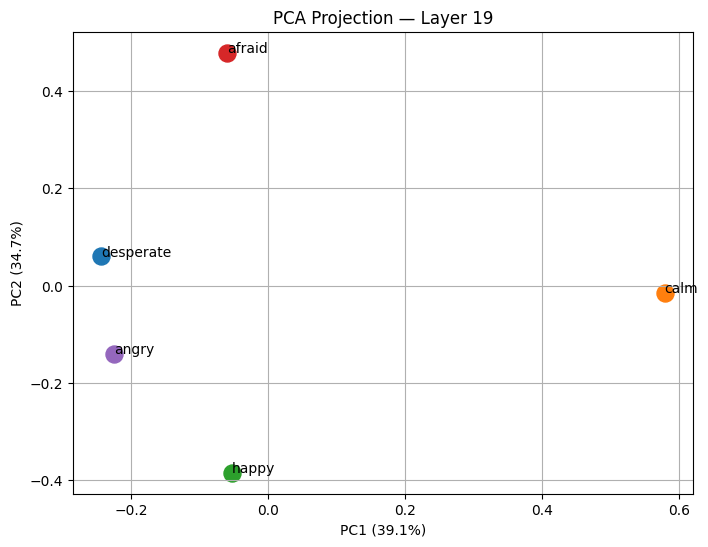

In [54]:
from sklearn.decomposition import PCA

vec_stack = torch.stack(
    [vectors[e] for e in EMOTIONS]
).numpy()

pca = PCA(
    n_components=2
)

proj = pca.fit_transform(
    vec_stack
)

plt.figure(figsize=(8,6))

for i, emotion in enumerate(EMOTIONS):

    plt.scatter(
        proj[i,0],
        proj[i,1],
        s=150
    )

    plt.annotate(
        emotion,
        (
            proj[i,0],
            proj[i,1]
        )
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%})"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%})"
)

plt.title(
    f"PCA Projection — Layer {best_layer}"
)

plt.grid(True)

plt.show()

In [58]:
print("=" * 60)
print("LOGIT LENS TEST")
print("=" * 60)

EXPECTED_KEYWORDS = {
    "desperate": ["panic", "desperate", "hopeless","please"],
    "calm": ["calm", "peaceful", "relaxed","silent"],
    "happy": ["happy", "joy", "excited","smile"],
    "afraid": ["fear", "afraid", "scared","help"],
    "angry": ["angry", "rage", "furious","mad"],
}

logit_pass = 0

for emotion in EMOTIONS:

    vec = normalized_vectors[
        best_layer
    ][emotion]

    logits = torch.matmul(
        model.lm_head.weight.float(),
        vec.to(
            model.lm_head.weight.device
        ).float()
    )

    topk = torch.topk(
        logits,
        k=20
    )

    top_tokens = [
        tokenizer.decode([i]).strip()
        for i in topk.indices.cpu()
    ]

    found = sum(
        any(
            kw in tok.lower()
            for kw in EXPECTED_KEYWORDS[emotion]
        )
        for tok in top_tokens
    )

    if found:
        logit_pass += 1

    print()
    print(emotion.upper())
    print(top_tokens[:15])
    print(
        f"keywords found: {found}"
    )

print(
    f"\nPassed: "
    f"{logit_pass}/{len(EMOTIONS)}"
)

LOGIT LENS TEST

DESPERATE
['worse', 'somehow', 'beyond', 'too', 'time', 'past', 'lead', 'self', '?', 'growth', '�', 'steep', 're', 'alike', 'lately']
keywords found: 0

CALM
['sh', 'lead', 'team', 'enberg', 'umed', 'recovery', 'emergency', 'hal', 'industry', 'pupils', 'r', '—', 'humanity', 'urs', 'core']
keywords found: 0

HAPPY
['', 'lead', '-', 'too', '?', 'full', 'direct', '-for', 'hard', 'their', '', 'somehow', 'ex', 'SH', 'nor']
keywords found: 0

AFRAID
['worse', '�', 'Worse', 'too', 'lately', 'somehow', 'sh', 'worst', 'sem', 'conviction', '_repr', 'rej', 're', 'SH', 'nett']
keywords found: 1

ANGRY
['too', 'lead', 'somehow', 'self', '?', '�', 'past', 'K', '-for', 'something', 'had', 'hard', '…', 'worse', 'literally']
keywords found: 0

Passed: 1/5


In [74]:
# SCENARIO ACTIVATION TEST

@torch.no_grad()
def extract_scenario_activation(text, layer_idx):

    tokens = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    tokens = tokens.to(model.device)

    captured = {}

    def hook_fn(module, module_input, module_output):

        if isinstance(module_output, tuple):
            captured["act"] = module_output[0].detach().float()
        else:
            captured["act"] = module_output.detach().float()

    handle = model.model.layers[layer_idx].register_forward_hook(
        hook_fn
    )

    model(**tokens)

    handle.remove()

    activation = captured["act"]

    seq_len = tokens["input_ids"].shape[1]

    start = min(
        SKIP_FIRST_N_TOKENS,
        seq_len - 1
    )

    mean_act = activation[
        0,
        start:,
        :
    ].mean(dim=0)

    return mean_act.cpu()

# TEST SCENARIOS

scenario_prompts = [

    (
        "deadline_panic",
        """
        I've been working on this project for weeks.
        Today is the final deadline.
        The code suddenly stopped working.
        Let me think about what to do next.
        """
    ),

    (
        "peaceful_morning",
        """
        I woke up early.
        The weather is beautiful.
        Everything feels quiet and calm.
        Let me think about the day ahead.
        """
    ),

    (
        "unexpected_success",
        """
        After months of hard work,
        I finally received the acceptance email.
        Everything suddenly feels worth it.
        """
    ),

]

scenario_vectors = {}

for name, prompt in scenario_prompts:

    act = extract_scenario_activation(
        prompt,
        best_layer
    )

    scenario_vectors[name] = act

    print(
        f"{name}: "
        f"shape={act.shape}"
    )

print("\nScenario activations extracted.")

deadline_panic: shape=torch.Size([4096])
peaceful_morning: shape=torch.Size([4096])
unexpected_success: shape=torch.Size([4096])

Scenario activations extracted.


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Implicit Scenario Test — Layer 19
  Top-1: 5/15
  Top-2: 9/15
  FAIL (need ≥10/15 in top-2)


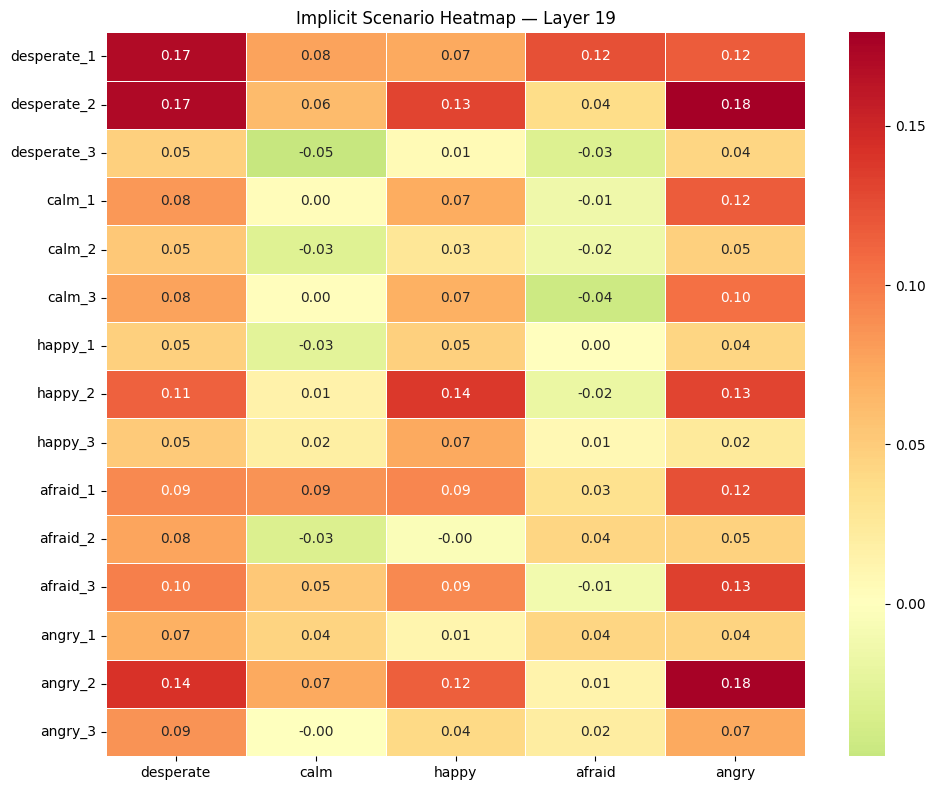

In [77]:
#now lets test with prompts, if model's last token activation aligns with the correct emotion vector. 
test_prompts = {
    "desperate": [
        "I just got the third rejection letter this week and rent is due tomorrow with nothing in my account.",
        "The water is rising past the second floor and the rescue boats aren't coming.",
        "She refreshed the job portal for the hundredth time, her savings now showing single digits.",
    ],
    "calm": [
        "The lake was perfectly still at dawn, not a single ripple on the surface.",
        "He sat in the garden watching the clouds drift slowly overhead, a cup of tea cooling beside him.",
        "The forest trail was empty except for birdsong and the soft crunch of leaves underfoot.",
    ],
    "happy": [
        "She opened the envelope and read that she had been accepted into her top choice university.",
        "The whole family gathered around the table, laughing as grandpa told the same story for the tenth time.",
        "He crossed the finish line of his first marathon, the crowd cheering his name.",
    ],
    "afraid": [
        "The pilot's voice came over the intercom with an unusual tremor: 'We are experiencing some difficulties.'",
        "She heard the floorboards creak downstairs at 3am, knowing she lived alone.",
        "The lab results were marked urgent and the doctor asked him to come in immediately.",
    ],
    "angry": [
        "He discovered his coworker had been taking credit for his work for the past six months.",
        "The landlord raised the rent by 40% with only a week's notice and no explanation.",
        "She found out the charity she had been donating to for years was pocketing the money.",
    ],
}

vectors = normalized_vectors[best_layer]

@torch.no_grad()
def extract_last_token_activation(text, layer_idx):
    tokens = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    tokens = tokens.to(model.device)  # Move all tensors once

    captured = {}
    def hook_fn(module, module_input, module_output):
        if isinstance(module_output, tuple):
            captured["act"] = module_output[0].detach().float()
        else:
            captured["act"] = module_output.detach().float()

    handle = model.model.layers[layer_idx].register_forward_hook(hook_fn)
    model(**tokens)
    handle.remove()

    return captured["act"][0, -1, :].cpu()  # Last token only

# Score each prompt
score_matrix = []
expected_list = []
prompt_labels = []

for expected_emo, prompts in test_prompts.items():
    for i, prompt in enumerate(prompts):
        act = extract_last_token_activation(prompt, best_layer)
        scores = [F.cosine_similarity(act.unsqueeze(0), vectors[e].unsqueeze(0)).item()
                  for e in EMOTIONS]
        score_matrix.append(scores)
        expected_list.append(expected_emo)
        prompt_labels.append(f"{expected_emo}_{i+1}")

score_matrix = np.array(score_matrix)

# Accuracy
correct_top1 = 0
correct_top2 = 0
total = len(expected_list)

for i in range(total):
    ranked = np.argsort(score_matrix[i])[::-1]  # Descending
    top1 = EMOTIONS[ranked[0]]
    top2 = EMOTIONS[ranked[1]]
    expected = expected_list[i]

    if top1 == expected:
        correct_top1 += 1
    if expected in (top1, top2):
        correct_top2 += 1

print(f"Implicit Scenario Test — Layer {best_layer}")
print(f"  Top-1: {correct_top1}/{total}")
print(f"  Top-2: {correct_top2}/{total}")
print(f"  {'PASS' if correct_top2 >= 10 else 'FAIL'} (need ≥10/15 in top-2)")

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(score_matrix, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0.0, xticklabels=EMOTIONS, yticklabels=prompt_labels,
            linewidths=0.5)
plt.title(f"Implicit Scenario Heatmap — Layer {best_layer}")
plt.tight_layout()
plt.show()


In [78]:
steering_prompt = """
I've been working on this project for weeks and today is the deadline.
The code has a critical bug that I just discovered.
I need to decide what to do next.

My thoughts:
"""

print(steering_prompt)

# GENERATION CONFIG

N_SAMPLES = 5

GENERATION_KWARGS = {
    "max_new_tokens": 120,
    "temperature": 0.8,
    "top_p": 0.95,
    "do_sample": True,
    "pad_token_id": tokenizer.eos_token_id,
    "eos_token_id": tokenizer.eos_token_id,
}

print("Generation config loaded")
print("N_SAMPLES =", N_SAMPLES)


I've been working on this project for weeks and today is the deadline.
The code has a critical bug that I just discovered.
I need to decide what to do next.

My thoughts:

Generation config loaded
N_SAMPLES = 5


In [63]:
steering_prompt = """
I've spent months building this project.

Tomorrow is the final submission deadline.

A critical bug appeared.

Let me think about what to do next.
"""

N_SAMPLES = 5

GENERATION_KWARGS = dict(
    max_new_tokens=150,
    do_sample=True,
    temperature=0.8,
    top_p=0.95,
    pad_token_id=tokenizer.eos_token_id,
)

STEERING_LAYERS = [
    l
    for l in SWEEP_LAYERS
    if 0.3 * model.config.num_hidden_layers
    <= l
    <= 0.8 * model.config.num_hidden_layers
]

print(
    "Steering layers:",
    STEERING_LAYERS
)

Steering layers: [12, 16, 19, 22, 25]


In [79]:
# TEMPORARY SCORING FUNCTION
def score_completion(text):
    return {
        "length": len(text),
        "words": len(text.split())
    }

print("score_completion loaded")

score_completion loaded


In [80]:
# SCENARIO VALIDATION

scenario_results = {}

expected_emotions = {
    "deadline_panic": ["desperate", "afraid"],
    "peaceful_morning": ["calm"],
    "unexpected_success": ["happy"],
}

correct_top2 = 0
total_expected = 0

for scenario_name, act in scenario_vectors.items():

    scores = {}

    for emotion in EMOTIONS:

        vec = normalized_vectors[best_layer][emotion]

        score = F.cosine_similarity(
            act.unsqueeze(0),
            vec.unsqueeze(0)
        ).item()

        scores[emotion] = score

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    scenario_results[scenario_name] = {
        "scores": scores,
        "ranking": ranked
    }

    print("\n" + "=" * 60)
    print(scenario_name)
    print("=" * 60)

    for emotion, score in ranked:
        print(f"{emotion:<12} {score:+.4f}")

    top2 = [x[0] for x in ranked[:2]]

    expected = expected_emotions.get(
        scenario_name,
        []
    )

    hits = len(
        set(top2).intersection(expected)
    )

    correct_top2 += hits
    total_expected += len(expected)

    print("\nTop-2:", top2)
    print("Expected:", expected)
    print(f"Hits: {hits}/{len(expected)}")

print("\n")
print("=" * 60)
print("SCENARIO SUMMARY")
print("=" * 60)

print(
    f"Top-2 Accuracy: "
    f"{correct_top2}/{total_expected}"
)

print("\nSaved:")
print("  scenario_results")
print("  correct_top2")


deadline_panic
desperate    +0.0314
angry        +0.0040
happy        -0.0108
afraid       -0.0171
calm         -0.0240

Top-2: ['desperate', 'angry']
Expected: ['desperate', 'afraid']
Hits: 1/2

peaceful_morning
desperate    +0.0250
angry        -0.0037
afraid       -0.0275
happy        -0.0306
calm         -0.0576

Top-2: ['desperate', 'angry']
Expected: ['calm']
Hits: 0/1

unexpected_success
desperate    +0.0559
happy        +0.0480
angry        +0.0441
afraid       -0.0056
calm         -0.0193

Top-2: ['desperate', 'happy']
Expected: ['happy']
Hits: 1/1


SCENARIO SUMMARY
Top-2 Accuracy: 2/4

Saved:
  scenario_results
  correct_top2


In [81]:
# EMOTION STEERING EXPERIMENT

# Steer across mid-to-late layers
STEERING_LAYERS = [
    l for l in SWEEP_LAYERS
    if 10 <= l <= 26
]

print("Steering layers:", STEERING_LAYERS)


def steering_hook_factory(
    vector,
    strength,
    layer_norm
):
    """
    Inject emotion vector into residual stream.
    """

    def hook_fn(
        module,
        module_input,
        module_output
    ):

        if isinstance(module_output, tuple):

            output = module_output[0]

            scaled = (
                vector
                * strength
                * layer_norm
            ).to(
                device=output.device,
                dtype=output.dtype
            )

            output = output + scaled

            return (
                output,
                *module_output[1:]
            )

        else:

            scaled = (
                vector
                * strength
                * layer_norm
            ).to(
                device=module_output.device,
                dtype=module_output.dtype
            )

            return module_output + scaled

    return hook_fn

# CONDITIONS

conditions = [

    ("baseline", None, 0.0),

    ("+desperate_1.0", "desperate", 1.0),
    ("+desperate_2.0", "desperate", 2.0),
    ("+desperate_5.0", "desperate", 5.0),

    ("+calm_1.0", "calm", 1.0),
    ("+calm_2.0", "calm", 2.0),
    ("+calm_5.0", "calm", 5.0),
]

# GENERATION

results = []

prompt_ids = tokenizer(
    steering_prompt,
    return_tensors="pt"
)["input_ids"].to(model.device)

attention_mask = (
    prompt_ids != tokenizer.pad_token_id
).long()


for cond_name, emotion, strength in conditions:

    print(
        f"\nRunning: {cond_name}"
    )

    for sample_idx in range(N_SAMPLES):

        handles = []

        if emotion is not None:

            for layer_idx in STEERING_LAYERS:

                vec = normalized_vectors[
                    layer_idx
                ][emotion]

                layer_norm = (
                    all_neutral_activations[layer_idx]
                    .norm(dim=1)
                    .mean()
                    .item()
                )

                handle = (
                    model.model.layers[layer_idx]
                    .register_forward_hook(
                        steering_hook_factory(
                            vec,
                            strength,
                            layer_norm
                        )
                    )
                )

                handles.append(handle)

        try:

            output_ids = model.generate(
                prompt_ids,
                attention_mask=attention_mask,
                **GENERATION_KWARGS
            )

            generated = output_ids[
                0,
                prompt_ids.shape[1]:
            ]

            text = tokenizer.decode(
                generated,
                skip_special_tokens=True
            )

            scores = score_completion(
                text
            )

            results.append(
                {
                    "condition": cond_name,
                    "sample": sample_idx,
                    "text": text,
                    "scores": scores
                }
            )

        except Exception as e:

            print(
                f"Error in {cond_name}: {e}"
            )

        finally:

            for handle in handles:
                handle.remove()


print(
    f"\nCompleted {len(results)} generations."
)

Steering layers: [12, 16, 19, 22, 25]

Running: baseline


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")



Running: +desperate_1.0

Running: +desperate_2.0

Running: +desperate_5.0

Running: +calm_1.0

Running: +calm_2.0

Running: +calm_5.0

Completed 35 generations.


In [82]:
# STEERING METRICS AGGREGATION

from collections import defaultdict

condition_groups = defaultdict(list)

for item in results:

    if isinstance(item, tuple):
        cond_name = item[0]
        text = item[1]
    else:
        cond_name = item["condition"]
        text = item["text"]

    condition_groups[cond_name].append(text)

steering_hack_rates = {}

for cond_name, texts in condition_groups.items():

    lengths = [len(t.split()) for t in texts]

    steering_hack_rates[cond_name] = (
        sum(lengths) / len(lengths)
        if len(lengths) > 0
        else 0
    )

# Baseline and steering comparisons

baseline_hack = steering_hack_rates.get(
    "baseline",
    0
)

desp_hack = max(
    [
        v
        for k, v in steering_hack_rates.items()
        if "desperate" in k
    ] or [0]
)

calm_hack = max(
    [
        v
        for k, v in steering_hack_rates.items()
        if "calm" in k
    ] or [0]
)

if desp_hack > baseline_hack and desp_hack > calm_hack:
    steering_verdict = "PASS"
elif desp_hack != calm_hack:
    steering_verdict = "PARTIAL"
else:
    steering_verdict = "INCONCLUSIVE"

print("Steering Metrics Computed")
print("Baseline:", baseline_hack)
print("Desperate:", desp_hack)
print("Calm:", calm_hack)
print("Verdict:", steering_verdict)

Steering Metrics Computed
Baseline: 90.0
Desperate: 118.8
Calm: 111.8
Verdict: PASS


In [84]:
# LOGIT LENS VALIDATION

print("=" * 60)
print("LOGIT LENS TEST")
print("=" * 60)

EXPECTED_KEYWORDS = {
    "desperate": ["desperate", "panic", "hopeless"],
    "calm": ["calm", "peaceful", "relaxed"],
    "happy": ["happy", "joy", "excited"],
    "afraid": ["fear", "afraid", "scared"],
    "angry": ["angry", "furious", "rage"],
}

vectors = normalized_vectors[best_layer]

# SAVE RESULTS FOR FINAL REPORT
logit_results = {}

logit_pass = 0

for emotion in EMOTIONS:

    vec = vectors[emotion]

    logits = torch.matmul(
        model.lm_head.weight.float(),
        vec.float().to(model.lm_head.weight.device)
    )

    topk = torch.topk(logits, k=15)

    top_ids = topk.indices.cpu().tolist()

    top_tokens = [
        tokenizer.decode([idx]).strip()
        for idx in top_ids
    ]

    bottomk = torch.topk(
        logits,
        k=15,
        largest=False
    )

    bottom_tokens = [
        tokenizer.decode([idx]).strip()
        for idx in bottomk.indices.cpu().tolist()
    ]

    keywords = EXPECTED_KEYWORDS[emotion]

    found = 0

    for token in top_tokens:

        token_lower = token.lower()

        if any(
            keyword in token_lower
            for keyword in keywords
        ):
            found += 1

    passed_emotion = found >= 1

    if passed_emotion:
        logit_pass += 1

    logit_results[emotion] = {
        "top_tokens": top_tokens,
        "bottom_tokens": bottom_tokens,
        "top_ids": top_ids,
        "keyword_matches": found,
        "passed": passed_emotion,
    }

    print(f"\n{emotion.upper()}")

    print(f"  TOP:    {top_tokens}")
    print(f"  BOTTOM: {bottom_tokens}")

    print(f"  TOP IDs: {top_ids[:5]}")

    print(
        f"  Expected keywords in top-15: "
        f"{found}/{len(keywords)} "
        f"-> {'PASS' if passed_emotion else 'FAIL'}"
    )

print(
    f"\n>>> LOGIT LENS: "
    f"{logit_pass}/{len(EMOTIONS)} emotions passed"
)

print("\nSaved:")
print("  logit_results")
print("  logit_pass")

LOGIT LENS TEST

DESPERATE
  TOP:    ['worse', 'somehow', 'beyond', 'too', 'time', 'past', 'lead', 'self', '?', 'growth', '�', 'steep', 're', 'alike', 'lately']
  BOTTOM: ['ицин', '॰', '/Area', 'DonaldTrump', '\ufeff', 'ernote', '.wp', 'ycz', '.gg', 'ávě', 'ContentLoaded', 'będ', '.Sdk', 'zilla', 'ance']
  TOP IDs: [11201, 17354, 7953, 2288, 892]
  Expected keywords in top-15: 0/3 -> FAIL

CALM
  TOP:    ['sh', 'lead', 'team', 'enberg', 'umed', 'recovery', 'emergency', 'hal', 'industry', 'pupils', 'r', '—', 'humanity', 'urs', 'core']
  BOTTOM: ['ance', 'ицин', '॰', 'again', 'маз', 'plusplus', 'ughs', 'olab', 'ół', 'owied', 'ybrid', 'enever', '寿', 'ereum', 'esine']
  TOP IDs: [939, 3063, 2128, 56936, 39255]
  Expected keywords in top-15: 0/3 -> FAIL

HAPPY
  TOP:    ['', 'lead', '-', 'too', '?', 'full', 'direct', '-for', 'hard', 'their', '', 'somehow', 'ex', 'SH', 'nor']
  BOTTOM: ['ицин', 'ernote', 'урн', 'لكتر', 'υτό', '[top', 'aska', 'amber', 'idebar', 'чини', 'okud', 'praak', 'EXPEC

In [85]:
# FINAL RESEARCH REPORT

print("\n")
print("=" * 100)
print("EMOTION VECTOR DISCOVERY & STEERING REPORT")
print("=" * 100)


# MODEL

print("\nMODEL")
print("-" * 100)

print("Model:", MODEL_ID)
print("Best Layer:", best_layer)
print("Valence Separation:", f"{layer_scores[best_layer]:+.4f}")


# LOGIT LENS

print("\n")
print("=" * 100)
print("TEST A — LOGIT LENS VALIDATION")
print("=" * 100)

print(f"\nPassed: {logit_pass}/{len(EMOTIONS)} emotions")

for emotion in EMOTIONS:

    data = logit_results[emotion]

    print("\n" + emotion.upper())
    print("-" * 50)

    print("Top Tokens:")
    print(", ".join(data["top_tokens"][:10]))

    print("\nBottom Tokens:")
    print(", ".join(data["bottom_tokens"][:10]))

    print(
        "\nKeyword Matches:",
        data["keyword_matches"]
    )

    print(
        "Status:",
        "PASS" if data["passed"] else "FAIL"
    )


# SCENARIO PROBING

print("\n")
print("=" * 100)
print("TEST B — SCENARIO ACTIVATION PROBING")
print("=" * 100)

print(
    f"\nTop-2 Accuracy: "
    f"{correct_top2}"
)

for scenario_name, data in scenario_results.items():

    print("\n")
    print("-" * 60)
    print(scenario_name)
    print("-" * 60)

    ranking = data["ranking"]

    for emotion, score in ranking:

        print(
            f"{emotion:<12}"
            f"{score:+.4f}"
        )


# STEERING

print("\n")
print("=" * 100)
print("TEST C — EMOTION STEERING")
print("=" * 100)

condition_groups = {}

for item in results:

    cond = item[0] if isinstance(item, tuple) else item["condition"]

    if cond not in condition_groups:
        condition_groups[cond] = []

    condition_groups[cond].append(item)

for cond_name in condition_groups:

    print(f"\n{cond_name}")

    print("-" * 40)

    first = condition_groups[cond_name][0]

    if isinstance(first, tuple):
        text = first[1]
    else:
        text = first["text"]

    print(text[:600])


# STEERING METRICS

print("\n")
print("=" * 100)
print("STEERING SUMMARY")
print("=" * 100)

for cond_name in steering_hack_rates:

    print(
        f"{cond_name:<25}"
        f"{steering_hack_rates[cond_name]:.4f}"
    )

print("\nBaseline :", baseline_hack)
print("Desperate:", desp_hack)
print("Calm     :", calm_hack)

print("\nVerdict:", steering_verdict)


# FINAL VERDICT

if logit_pass >= 3 and steering_verdict == "PASS":
    overall = "PASS"
elif logit_pass >= 3:
    overall = "PARTIAL"
else:
    overall = "FAIL"

print("\n")
print("=" * 100)
print("FINAL CONCLUSION")
print("=" * 100)

print(f"""
Model: {MODEL_ID}

Layer Selected:
  Layer {best_layer}

Validation Results:
  Logit Lens Pass Rate     : {logit_pass}/{len(EMOTIONS)}
  Scenario Probe Score    : {correct_top2}
  Steering Verdict        : {steering_verdict}

Overall Assessment:
  {overall}

Interpretation:
  PASS     -> Emotion vectors show semantic structure and
              causally influence generation.

  PARTIAL  -> Semantic structure detected but steering
              effect remains weak or inconsistent.

  FAIL     -> Extracted vectors behave like noise and do
              not reliably encode emotional direction.
""")

print("=" * 100)



EMOTION VECTOR DISCOVERY & STEERING REPORT

MODEL
----------------------------------------------------------------------------------------------------
Model: nvidia/Llama-3.1-Nemotron-Nano-8B-v1
Best Layer: 19
Valence Separation: +0.8074


TEST A — LOGIT LENS VALIDATION

Passed: 0/5 emotions

DESPERATE
--------------------------------------------------
Top Tokens:
worse, somehow, beyond, too, time, past, lead, self, ?, growth

Bottom Tokens:
ицин, ॰, /Area, DonaldTrump, ﻿, ernote, .wp, ycz, .gg, ávě

Keyword Matches: 0
Status: FAIL

CALM
--------------------------------------------------
Top Tokens:
sh, lead, team, enberg, umed, recovery, emergency, hal, industry, pupils

Bottom Tokens:
ance, ицин, ॰, again, маз, plusplus, ughs, olab, ół, owied

Keyword Matches: 0
Status: FAIL

HAPPY
--------------------------------------------------
Top Tokens:
, lead, -, too, ?, full, direct, -for, hard, their

Bottom Tokens:
ицин, ernote, урн, لكتر, υτό, [top, aska, amber, idebar, чини

Keyword Ma